In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("congressional_voting_records.csv")

In [ ]:
df.head()

,Class,handicapped_infants,water_project_cost_sharing,adoption_of_the_budget_resolution,physician_fee_freeze,el_salvador_aid,religious_groups_in_schools,anti_satellite_test_ban,aid_to_nicaraguan_contras,mx_missile,immigration,synfuels_corporation_cutback,education_spending,superfund_right_to_sue,crime,duty_free_exports,export_administration_act_south_africa
0,republican,n,y,n,y,y,y,n,n,n,y,NaN,y,y,y,n,y
1,republican,n,y,n,y,y,y,n,n,n,n,n,y,y,y,n,NaN
2,democrat,NaN,y,y,NaN,y,y,n,n,n,n,y,n,y,y,n,n
3,democrat,n,y,y,n,NaN,y,n,n,n,n,y,n,y,n,n,y
4,democrat,y,y,y,n,y,y,n,n,n,n,y,NaN,y,y,y,y


In [ ]:
df.tail()

,Class,handicapped_infants,water_project_cost_sharing,adoption_of_the_budget_resolution,physician_fee_freeze,el_salvador_aid,religious_groups_in_schools,anti_satellite_test_ban,aid_to_nicaraguan_contras,mx_missile,immigration,synfuels_corporation_cutback,education_spending,superfund_right_to_sue,crime,duty_free_exports,export_administration_act_south_africa
430,republican,n,n,y,y,y,y,n,n,y,y,n,y,y,y,n,y
431,democrat,n,n,y,n,n,n,y,y,y,y,n,n,n,n,n,y
432,republican,n,NaN,n,y,y,y,n,n,n,n,y,y,y,y,n,y
433,republican,n,n,n,y,y,y,NaN,NaN,NaN,NaN,n,y,y,y,n,y
434,republican,n,y,n,y,y,y,n,n,n,y,n,y,y,y,NaN,n


In [ ]:
df.isna().sum()

Class                                       0
handicapped_infants                        12
water_project_cost_sharing                 48
adoption_of_the_budget_resolution          11
physician_fee_freeze                       11
el_salvador_aid                            15
religious_groups_in_schools                11
anti_satellite_test_ban                    14
aid_to_nicaraguan_contras                  15
mx_missile                                 22
immigration                                 7
synfuels_corporation_cutback               21
education_spending                         31
superfund_right_to_sue                     25
crime                                      17
duty_free_exports                          28
export_administration_act_south_africa    104
dtype: int64

In [ ]:
cate=["handicapped_infants","water_project_cost_sharing","adoption_of_the_budget_resolution","physician_fee_freeze","el_salvador_aid","religious_groups_in_schools","anti_satellite_test_ban","aid_to_nicaraguan_contras","mx_missile","immigration","synfuels_corporation_cutback","education_spending","superfund_right_to_sue","crime","duty_free_exports","export_administration_act_south_africa"]

In [ ]:
for i in cate:
    df[i]=df[i].fillna(df[i].mode()[0])

In [ ]:
df.isna().sum()

Class                                     0
handicapped_infants                       0
water_project_cost_sharing                0
adoption_of_the_budget_resolution         0
physician_fee_freeze                      0
el_salvador_aid                           0
religious_groups_in_schools               0
anti_satellite_test_ban                   0
aid_to_nicaraguan_contras                 0
mx_missile                                0
immigration                               0
synfuels_corporation_cutback              0
education_spending                        0
superfund_right_to_sue                    0
crime                                     0
duty_free_exports                         0
export_administration_act_south_africa    0
dtype: int64

In [ ]:
df.duplicated

<bound method DataFrame.duplicated of           Class handicapped_infants water_project_cost_sharing  \
0    republican                   n                          y   
1    republican                   n                          y   
2      democrat                   n                          y   
3      democrat                   n                          y   
4      democrat                   y                          y   
..          ...                 ...                        ...   
430  republican                   n                          n   
431    democrat                   n                          n   
432  republican                   n                          y   
433  republican                   n                          n   
434  republican                   n                          y   

    adoption_of_the_budget_resolution physician_fee_freeze el_salvador_aid  \
0                                   n                    y               y   
1            

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dtypes

Class                                     str
handicapped_infants                       str
water_project_cost_sharing                str
adoption_of_the_budget_resolution         str
physician_fee_freeze                      str
el_salvador_aid                           str
religious_groups_in_schools               str
anti_satellite_test_ban                   str
aid_to_nicaraguan_contras                 str
mx_missile                                str
immigration                               str
synfuels_corporation_cutback              str
education_spending                        str
superfund_right_to_sue                    str
crime                                     str
duty_free_exports                         str
export_administration_act_south_africa    str
dtype: object

<BarContainer object of 2 artists>

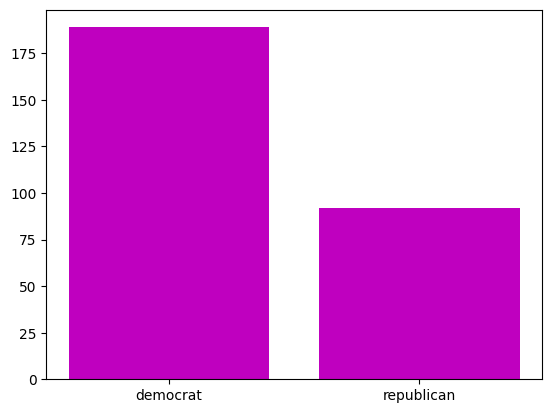

In [ ]:
clas=df["Class"].value_counts()
plt.bar(clas.index,clas.values,color="m")

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
columns=["Class","handicapped_infants","water_project_cost_sharing","adoption_of_the_budget_resolution","physician_fee_freeze","el_salvador_aid","religious_groups_in_schools","anti_satellite_test_ban","aid_to_nicaraguan_contras","mx_missile","immigration","synfuels_corporation_cutback","education_spending","superfund_right_to_sue","crime","duty_free_exports","export_administration_act_south_africa"]
for col in columns:
    df[col]=le.fit_transform(df[col])

In [ ]:
df.dtypes

Class                                     int64
handicapped_infants                       int64
water_project_cost_sharing                int64
adoption_of_the_budget_resolution         int64
physician_fee_freeze                      int64
el_salvador_aid                           int64
religious_groups_in_schools               int64
anti_satellite_test_ban                   int64
aid_to_nicaraguan_contras                 int64
mx_missile                                int64
immigration                               int64
synfuels_corporation_cutback              int64
education_spending                        int64
superfund_right_to_sue                    int64
crime                                     int64
duty_free_exports                         int64
export_administration_act_south_africa    int64
dtype: object

In [ ]:
x=df.drop(columns="Class")
y=df["Class"]

In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.30)

In [ ]:
from sklearn.naive_bayes import BernoulliNB
model=BernoulliNB()

In [ ]:
model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[137., 59.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.36,-1.2 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 16)","[[ 71., 81.,113.,..., 68., 71.,128.], [ 17., 30., 12.,..., 58., 10., 45.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 16)","[[-0.66,-0.53,-0.2 ,...,-0.7 ,-0.66,-0.07], [-1.22,-0.68,-1.55,...,-0.03,-1.71,-0.28]]"


In [ ]:
y_pred=model.predict(x_test)

In [ ]:
y_test

21     0
22     0
20     0
355    1
136    1
      ..
292    0
351    1
393    1
55     1
93     0
Name: Class, Length: 85, dtype: int64

In [ ]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_pred,y_test)
cm

array([[41,  6],
       [11, 27]])

In [ ]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_pred,y_test)
acc

0.8